# 03 - Interpretasi Model

Notebook ini menjelaskan interpretasi model terbaik untuk klasifikasi gesture tangan kanan. Interpretasi dilakukan melalui permutation importance agar tetap kompatibel dengan model terbaik apa pun yang tersimpan.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

from src.feature_extraction import feature_columns

MODEL_PATH = ROOT / 'models/best_model.joblib'
artifact = joblib.load(MODEL_PATH)
model = artifact['model']
x_test = artifact['x_test']
y_test = artifact['y_test']
label_encoder = artifact['label_encoder']

print('Model terbaik:', artifact['model_name'])
print('Kelas:', list(label_encoder.classes_))

Model terbaik: knn
Kelas: ['idle', 'right_arrow_left', 'right_arrow_right', 'right_click', 'right_cursor']


## Permutation Importance

Permutation importance mengukur seberapa besar performa model turun ketika nilai suatu fitur diacak. Fitur dengan nilai importance tinggi berarti berperan besar dalam keputusan model.

In [2]:
result = permutation_importance(
    model,
    x_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro',
)

importance = pd.DataFrame({
    'feature': feature_columns(),
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std,
}).sort_values('importance_mean', ascending=False)

importance.head(15)

,feature,importance_mean,importance_std
53,z17,0.004501,0.001500
41,z13,0.004001,0.002000
38,z12,0.004001,0.002000
44,z14,0.003501,0.002292
32,z10,0.003501,0.002292
35,z11,0.003501,0.002292
56,z18,0.003000,0.002450
59,z19,0.003000,0.002450
62,z20,0.002000,0.002450
26,z8,0.001000,0.002000


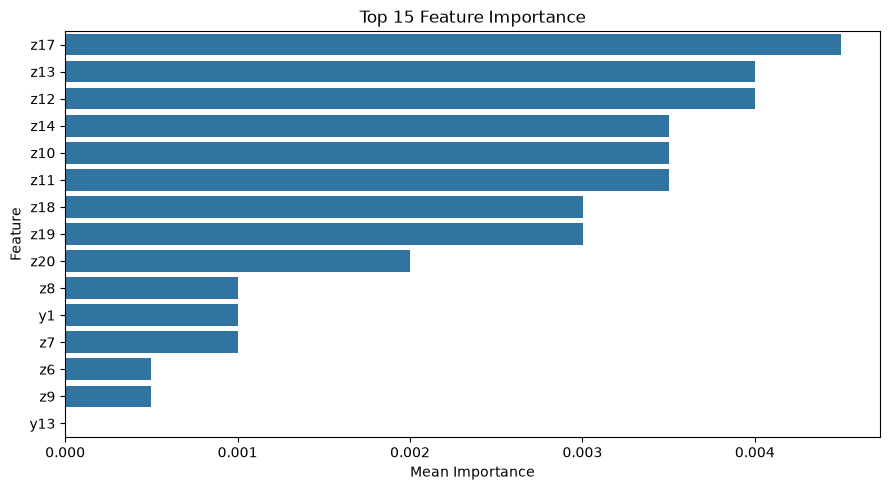

In [3]:
top_features = importance.head(15)
plt.figure(figsize=(9, 5))
sns.barplot(data=top_features, x='importance_mean', y='feature')
plt.title('Top 15 Feature Importance')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Interpretasi Bisnis / Sistem

Fitur yang paling penting biasanya berasal dari landmark ujung jari dan sendi jari, seperti ibu jari, telunjuk, jari tengah, jari manis, dan kelingking. Hal ini sesuai dengan desain kontrol:

- `right_cursor` bergantung pada posisi telunjuk.
- `right_click` bergantung pada jarak ibu jari dan telunjuk.
- `right_arrow_left` bergantung pada gesture dua jari.
- `right_arrow_right` bergantung pada gesture tiga jari.
- `idle` merepresentasikan kondisi tanpa gesture aksi.

Dengan interpretasi ini, model tidak hanya memberikan prediksi, tetapi juga dapat dijelaskan berdasarkan bagian tangan yang memang relevan terhadap kontrol game.

## Risiko dan Rekomendasi

- Dataset saat ini berasal dari kondisi perekaman tertentu, sehingga model perlu diuji pada pencahayaan dan jarak yang lebih beragam.
- Tambahkan sampel dari beberapa pengguna agar model lebih general.
- Jika prediksi gesture masih terlalu sensitif, gabungkan prediksi model dengan smoothing atau voting beberapa frame.
- Untuk kontrol analog tangan kiri, rule-based tetap lebih cocok karena outputnya berupa arah kontinu, bukan kelas diskrit.

## Kesimpulan Interpretasi

Model gesture berbasis landmark MediaPipe dapat dijelaskan melalui kontribusi fitur landmark. Fitur penting merepresentasikan posisi jari yang memang digunakan dalam rancangan gesture controller, sehingga hasil model selaras dengan kebutuhan sistem.